In [6]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

from project_01_market_risk_engine.src.data import download_prices

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Portfolio Construction

This notebook defines the investment portfolio used by the market risk engine and calculates portfolio-level return and risk measures.

The portfolio consists of multiple asset classes with explicitly defined weights.

The analysis covers:

1. Portfolio definition
   1. Portfolio Tickers
   2. Portfolio weights
2. Portfolio returns
3. Portfolio volatility
4. Diversification effects
5. Contribution of individual assets to portfolio risk

### 1. Portfolio Definition

The portfolio is intentionally diversified across equity, fixed-income and commodity exposures.

The initial allocation is:

- SPY: 30%
- QQQ: 20%
- IWM: 15%
- TLT: 20%
- GLD: 15%

The weights sum to 100% and will be used consistently throughout the risk engine.

In [7]:
TICKERS = [
    "SPY",
    "QQQ",
    "IWM",
    "TLT",
    "GLD"
]

START_DATE = "2015-01-01"
END_DATE = "2026-01-01"

weights = pd.Series({
     "SPY": 0.30,
    "QQQ" : 0.20,
    "IWM" : 0.15,
    "TLT" : 0.20,
    "GLD" : 0.15  
})




In [ ]:
prices = download_prices(
    tickers=TICKERS,
    start=START_DATE,
    end=END_DATE
)

returns = prices.pct_change().dropna()


[*********************100%***********************]  5 of 5 completed


Date
2015-01-05   -0.004954
2015-01-06   -0.002789
2015-01-07    0.006885
2015-01-08    0.008416
2015-01-09   -0.001263
                ...   
2025-12-24    0.002607
2025-12-26    0.000284
2025-12-29   -0.008733
2025-12-30   -0.002309
2025-12-31   -0.007570
Length: 2765, dtype: float64

### 2. Portfolio Returns

In [ ]:
portfolio_returns = returns @ weights

In [10]:
portfolio_returns.head()

Date
2015-01-05   -0.004954
2015-01-06   -0.002789
2015-01-07    0.006885
2015-01-08    0.008416
2015-01-09   -0.001263
dtype: float64

In [11]:
portfolio_returns.describe()

count    2765.000000
mean        0.000463
std         0.008090
min        -0.068361
25%        -0.003195
50%         0.000709
75%         0.004442
max         0.074988
dtype: float64

In [12]:
portfolio_returns.info()

<class 'pandas.Series'>
DatetimeIndex: 2765 entries, 2015-01-05 to 2025-12-31
Series name: None
Non-Null Count  Dtype  
--------------  -----  
2765 non-null   float64
dtypes: float64(1)
memory usage: 43.2 KB


### 3. Portfolio Volatility

In [ ]:
portfolio_daily_volatility = portfolio_returns.std()
portfolio_annualized_volatility = portfolio_daily_volatility * np.sqrt(252)
weighted_average_volatility = (returns.std() * np.sqrt(252) * weights).sum() 

In [22]:

print(
    f"Portfolio volatility: "
    f"{portfolio_annualized_volatility:.2%}"
)

print(
    f"Weighted average asset volatility: "
    f"{weighted_average_volatility:.2%}"
)



Portfolio volatility: 12.84%
Weighted average asset volatility: 18.33%


#### Key Observation

Since the assets are not perfectly correlated, the volatility of the portfolio is less than the weighted average volatility of individual assets.

In [18]:


returns.std() * weights

Ticker
GLD    0.001393
IWM    0.002129
QQQ    0.002769
SPY    0.003362
TLT    0.001895
dtype: float64

#### Calculate portfolio volatility from covariance

In [ ]:
portfolio_variance = weights.T @ returns.cov()*252 @ weights

portfolio_volatility_covariance = np.sqrt(portfolio_variance)

portfolio_volatility_covariance


np.float64(0.12842335493542942)

In [31]:
print(
    f"From portfolio returns: "
    f"{portfolio_annualized_volatility:.6f}"
)

print(
    f"From covariance matrix: "
    f"{portfolio_volatility_covariance:.6f}"
)

From portfolio returns: 0.128423
From covariance matrix: 0.128423


## 4. Portfolio Risk Attribution

Portfolio weights alone do not describe the contribution of each asset to portfolio risk.

Risk contribution depends on the asset's weight, its covariance with the portfolio and the overall portfolio volatility.

We calculate:

- Marginal Contribution to Risk (MCR)
- Component Contribution to Risk (CCR)
- Percentage Contribution to Risk

In [41]:
portfolio_volatility = portfolio_volatility_covariance
annualized_covariance = returns.cov()*252

marginal_contribution = (
    annualized_covariance @ weights
) / portfolio_volatility

component_contribution = (
    weights * marginal_contribution
)

percentage_contribution = (
    component_contribution / portfolio_volatility
)

In [44]:
risk_contribution_table = pd.DataFrame({
    "Weight": weights,
    "Marginal Contribution": marginal_contribution,
    "Component Contribution": component_contribution,
    "Percentage Contribution": percentage_contribution
})

risk_contribution_table

,Weight,Marginal Contribution,Component Contribution,Percentage Contribution
GLD,0.15,0.042261,0.006339,0.049361
IWM,0.15,0.193054,0.028958,0.225489
QQQ,0.20,0.200286,0.040057,0.311915
SPY,0.30,0.165086,0.049526,0.385644
TLT,0.20,0.017717,0.003543,0.027591


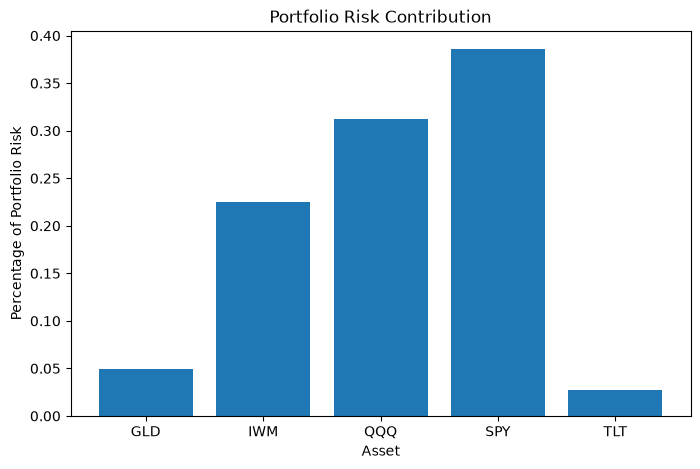

In [ ]:

plt.figure(figsize=(8, 5))

plt.bar(
    risk_contribution_table.index,
    risk_contribution_table["Percentage Contribution"]
)

plt.title("Portfolio Risk Contribution")
plt.xlabel("Asset")
plt.ylabel("Percentage of Portfolio Risk")

plt.show()


## Key Observations

The portfolio's capital allocation differs materially from its risk allocation.

SPY represents 30% of portfolio capital but contributes approximately 38.6% of total portfolio volatility. QQQ represents 20% of capital but contributes approximately 31.2% of portfolio volatility, while IWM represents 15% of capital but contributes approximately 22.5% of portfolio volatility.

In contrast, TLT represents 20% of portfolio capital but contributes only approximately 2.8% of total portfolio volatility. GLD represents 15% of capital but contributes approximately 4.9% of portfolio volatility.

The results demonstrate that portfolio weights alone do not adequately describe portfolio risk. Risk contribution depends on both the volatility of individual assets and their covariance with the rest of the portfolio.

The portfolio therefore has a greater concentration of risk in equity exposures than its capital allocation alone would suggest.